### 2. Breast Cancer Dataset Analysis

This notebook performs several steps on the `breast_cncr_prdctn1.csv` dataset, including data loading, preprocessing, model training, and evaluation.

### Loading the Dataset

**Reasoning:** The first step is to load the dataset from the provided CSV file into a pandas DataFrame. This allows us to easily manipulate and analyze the data.

**Operation:** We use `pd.read_csv()` to load the data and `df.head()` to display the first few rows, ensuring the data is loaded correctly and providing an initial glimpse of its structure.

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/breast_cncr_prdctn1.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,B,13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,...,15.11,19.26,99.70,711.2,0.1440,0.1773,0.2390,0.12880,0.2977,0.07259
4,B,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


### a. Identify Missing Values

**Reasoning:** Identifying missing values is crucial for data quality. Missing data can affect model performance and lead to biased results. Knowing where missing values exist helps decide on appropriate imputation or removal strategies.

**Operation:** We use `df.isnull().sum()` to count the number of missing values for each column in the DataFrame.

### c. Use label encoder to encode the categorical attribute 'diagnosis'

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'diagnosis' column
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print("Encoded 'diagnosis' column values (0 for Benign, 1 for Malignant):")
display(df['diagnosis'].value_counts())

Encoded 'diagnosis' column values (0 for Benign, 1 for Malignant):


,count
diagnosis,
1,7
0,7


### b. Find Total Cases of Each Group

**Reasoning:** Understanding the distribution of the target variable (`diagnosis`) is important. It helps assess class imbalance, which can influence model training. For a classification problem, knowing the number of instances for each class (Benign or Malignant) provides a baseline understanding of the dataset.

**Operation:** We use `df['diagnosis'].value_counts()` to count the occurrences of each unique value in the 'diagnosis' column.

### d. Use Standard Scaler to transform the dataset

### c. Use Label Encoder to Encode the Categorical Attribute "diagnosis"

**Reasoning:** Machine learning models typically require numerical input. The 'diagnosis' column is categorical (e.g., 'M' for Malignant, 'B' for Benign). Label Encoding converts these text labels into numerical format (e.g., 0 and 1) making them suitable for model training.

**Operation:** We instantiate `LabelEncoder` from `sklearn.preprocessing` and apply `fit_transform()` to the 'diagnosis' column. This converts the categorical labels to numerical ones and updates the DataFrame.

In [8]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled features:")
display(X_scaled_df.head())

First 5 rows of the scaled features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.882130,-1.849354,1.057068,0.789821,0.908769,2.099520,2.138973,1.954882,1.656242,1.177362,...,1.592740,-1.206210,1.967638,1.722296,0.750431,1.613589,1.896980,1.603984,1.170798,0.980742
1,1.604047,0.233535,1.474183,1.708077,-1.054772,-0.654854,-0.300943,0.140561,-0.277102,-0.776738,...,1.513088,0.161481,1.221069,1.613640,-0.694007,-0.556133,-0.436832,0.525548,-0.478836,-0.095982
2,1.357812,1.214381,1.354418,1.360552,0.395425,0.470098,0.963648,1.502068,0.541464,-0.482382,...,1.223075,0.638374,1.038768,1.187640,0.080873,0.521480,0.599315,1.299740,0.290281,-0.147872
3,-0.363037,-0.727582,-0.402425,-0.438381,-0.293506,-0.618168,-0.532804,-0.386778,-0.044591,-0.688963,...,-0.504752,-0.772058,-0.489093,-0.533264,0.065827,-0.598259,-0.449734,-0.251360,-0.276530,-0.688036
4,-0.491751,-0.347081,-0.478002,-0.569197,0.272922,0.014635,-0.772676,-0.780868,0.216585,0.237550,...,-0.629335,-0.495370,-0.593555,-0.672448,-0.415652,-0.143931,-0.697854,-1.011562,-0.092050,-0.355073


### d. Use Standard Scaler to Transform the Dataset

**Reasoning:** Many machine learning algorithms, especially those that calculate distances (like SVMs), are sensitive to the scale of features. `StandardScaler` normalizes features by subtracting the mean and dividing by the standard deviation, resulting in a mean of 0 and a standard deviation of 1. This prevents features with larger numerical ranges from dominating the model.

**Operation:** We first separate the features (X) from the target variable (y). Then, we initialize `StandardScaler` and apply `fit_transform()` to the feature set `X`. The scaled features are then converted back into a DataFrame for easier inspection.

### e. Then use Support Vector classifier to make the model learn and detect the cases of Benign or Malignancy.

### e. Use Support Vector Classifier to make the model learn and detect the cases of Benign or Malignancy.

**Reasoning:** Support Vector Machines (SVMs) are powerful classification algorithms that work well in high-dimensional spaces and are effective in cases where there is a clear margin of separation between classes. We use a Support Vector Classifier (SVC) to build a model that can predict whether a breast cancer case is Benign or Malignant based on the scaled features.

**Operations:**
1.  **Data Splitting:** We split the dataset into training and testing sets using `train_test_split()`. This ensures that the model is evaluated on unseen data, providing an unbiased estimate of its performance.
2.  **Model Initialization and Training:** An `SVC` model with a linear kernel is initialized and trained on the scaled training data (`X_train`, `y_train`).
3.  **Prediction:** The trained model makes predictions on the test set (`X_test`).
4.  **Accuracy Evaluation:** The `accuracy_score()` is calculated to measure the proportion of correctly classified instances.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize Support Vector Classifier
svc_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for simplicity

# Train the model
svc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svc_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.60


### f. Apply Confusion matrix for the test sets.

### f. Apply Confusion Matrix for the Test Sets

**Reasoning:** A confusion matrix is a performance measurement for machine learning classification problems where the output can be two or more classes. It provides a more detailed breakdown of model performance than just accuracy by showing the number of true positives, true negatives, false positives, and false negatives. This helps in understanding the types of errors the model is making.

**Operations:**
1.  **Generate Confusion Matrix:** `confusion_matrix()` is used to compute the confusion matrix based on the true labels (`y_test`) and the model's predictions (`y_pred`).
2.  **Visualization:** A heatmap using `seaborn` and `matplotlib` is generated to visually represent the confusion matrix, making it easier to interpret. The `xticklabels` and `yticklabels` are set to the original class names ('Benign', 'Malignant') for clarity.

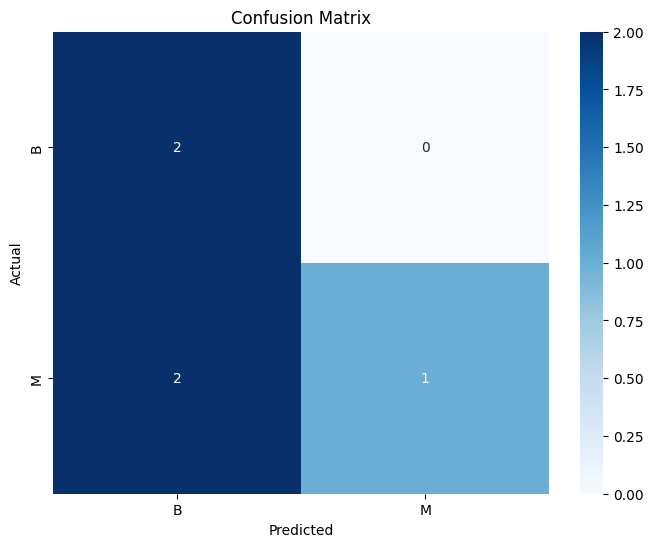

Confusion Matrix:


array([[2, 0],
       [2, 1]])

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:")
display(cm)